# Descripción

## 1 - Abrir el archivo de datos y leer la información general

In [1]:
#Importamos las librerias necesarias
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest

In [2]:
#Importamos el CSV como DataFrame
#Identficamos el separador como '   ' (*espaciado tab) para que lea correctamente los datos
logs = pd.read_csv('datasets/logs_exp_us.csv', sep='	')

In [3]:
#Realizamos la exploración inicial de los datos
print(logs.info())
#print(logs.describe())
print(logs.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB
None
                 EventName         DeviceIDHash  EventTimestamp  ExpId
235080    MainScreenAppear  5170479393138058165      1565192923    248
83482     CartScreenAppear  3316969965060175629      1564824436    247
40184   OffersScreenAppear  4130924338156292426      1564709540    247
40521   OffersScreenAppear  8376265912126549996      1564711264    248
243361  OffersScreenAppear  6385342596701301167      1565208885    246


    - Los datos aparentan no tener datos nulos, pero será necesario un mayor análisis con los datos nulos o incorrectos, así como se realizaran cambios en el formato de nombrado de las series de UpperCase a snake_case.
    - Se modificará el tipo de dato de la serie EventTimeStamp de object a datetime para su manejor posterior.
    - Se verificará si existen datos duplicados en el DF, en caso de haber será necesario evaluar si su eliminación no generará sesgo sobre los datos.

## 2 - Preparar los datos para el análisis

### 2.1 - Cambia el nombre de las columnas de manera que sea conveniente para ti.


In [4]:
#En lo personal utilizo el nombrado de snake_case para nombrar las columnas, acutalmente las columnas están en UpperCase
#Se creará una función para renombrar las columnas, encontrará las mayúsculas, para luego añadir un guión bajo antes y convirtiendo todo a minúsculas.
def rename_columns(list_columns):
    new_columns = []
    for i in range(len(list_columns)):
        text = re.sub(r'(?<!^)([A-Z])', r'_\1', list_columns[i])
        new_columns.append(text.lower())
    return new_columns

#Renombramos las columnas del DataFrame
logs.columns = rename_columns(logs.columns)
#Debido al nombrado de la columna 'DeviceIDHash' la palabra "ID" se ha convertido en '_i_d', lo cual no es correcto
#Corregimos de forma manual el nombre de la columna 'device_i_d_hash' a 'device_id_hash'
logs.rename(columns={'device_i_d_hash': 'device_id_hash'}, inplace=True)
#Mostramos las columnas renombradas
print(logs.columns)

Index(['event_name', 'device_id_hash', 'event_timestamp', 'exp_id'], dtype='object')


### 2.2 - Comprueba los tipos de datos y valores ausentes. Corrige los datos si es necesario.

In [5]:
#Convertimos la serie "event_timestamp" a tipo timestamp
logs['event_timestamp'] = pd.to_datetime(logs['event_timestamp'], unit='s')
#Mostramos el tipo de dato de la columna "event_timestamp"
print(logs['event_timestamp'].dtype)

#Verificamos si hay valores nulos en el DataFrame
print('Cantidad de valores nulos: ', logs.isnull().sum())

#Comprobamos si hay valores duplicados en el DataFrame
logs_duplicated = logs[logs.duplicated()]
print('\nCantidad de valores duplicados: ',logs_duplicated.shape)
print('\nPrimeros 3 duplas duplicadas:\n', logs[logs.duplicated(keep=False)].head(6))

#Eliminamos los valores duplicados del DataFrame
logs.drop_duplicates(inplace=True)
print('\nCantidad de valores duplicados (después de eliminación): ',logs.duplicated().sum())

datetime64[ns]
Cantidad de valores nulos:  event_name         0
device_id_hash     0
event_timestamp    0
exp_id             0
dtype: int64

Cantidad de valores duplicados:  (413, 4)

Primeros 3 duplas duplicadas:
             event_name       device_id_hash     event_timestamp  exp_id
452   MainScreenAppear  5613408041324010552 2019-07-30 08:19:44     248
453   MainScreenAppear  5613408041324010552 2019-07-30 08:19:44     248
2348  CartScreenAppear  1694940645335807244 2019-07-31 21:51:39     248
2350  CartScreenAppear  1694940645335807244 2019-07-31 21:51:39     248
3572  MainScreenAppear   434103746454591587 2019-08-01 02:59:37     248
3573  MainScreenAppear   434103746454591587 2019-08-01 02:59:37     248

Cantidad de valores duplicados (después de eliminación):  0


    - Al validar los datos duplicados se encontraron 413 registros de entre los 244,126 totales, y fueron eliminados. Esto acción se realizó basado en que la probabilidad de que los registros se realizarán durante el mismo evento, en el mismo dispositivo y al mismo día y hora es practicamente nula.
    - Los datos eliminados pertenecen a distintos grupos de control por lo que no se pude concluir con alguna razón en especifico para la aparición de este error.

### 2.3 - Agrega una columna de fecha y hora y una columna separada para las fechas.

In [6]:
#Creamos dos nuevas series una con la fecha y otra con la hora, llamadas "event_date" y "event_time"
logs['event_date'] = logs['event_timestamp'].dt.date
logs['event_time'] = logs['event_timestamp'].dt.time

logs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243713 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       243713 non-null  object        
 1   device_id_hash   243713 non-null  int64         
 2   event_timestamp  243713 non-null  datetime64[ns]
 3   exp_id           243713 non-null  int64         
 4   event_date       243713 non-null  object        
 5   event_time       243713 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 13.0+ MB


## 3 - Estudiar y comprobar los datos

### 3.1 - ¿Cuántos eventos hay en los registros?

In [38]:
#Contamos el número de eventos distintos en el dataframe
print('Cantidad de eventos en el DF:\n',logs['event_name'].value_counts())

Cantidad de eventos en el DF:
 event_name
MainScreenAppear           119101
OffersScreenAppear          46808
CartScreenAppear            42668
PaymentScreenSuccessful     34118
Tutorial                     1018
Name: count, dtype: int64


### 3.2 - ¿Cuántos usuarios hay en los registros?

In [8]:
#Contamos la cantidad de dispositivos únicos en el DataFrame
print('Cantidad de dispositivos únicos: ', logs['device_id_hash'].nunique())

Cantidad de dispositivos únicos:  7551


### 3.3 - ¿Cuál es el promedio de eventos por usuario?

In [9]:
#Calculamos la cantidad de eventos por dispositivo unico
device_event_count = logs.groupby('device_id_hash')['event_name'].count().reset_index()

#Renombramos la columna 'event_name' a 'event_count'
device_event_count.rename(columns={'event_name': 'event_count'}, inplace=True)

#Mostramos el promedio de eventos por dispositivo
print('Promedio de eventos por dispositivo: ', device_event_count['event_count'].mean())

Promedio de eventos por dispositivo:  32.27559263673685


### 3.4 - ¿Qué periodo de tiempo cubren los datos? Encuentra la fecha máxima y mínima. 
Traza un histograma por fecha y hora. ¿Puedes tener seguridad de que tienes datos igualmente completos para todo el periodo? Los eventos más antiguos podrían terminar en los registros de algunos usuarios por razones técnicas y esto podría sesgar el panorama general. Encuentra el momento en el que los datos comienzan a estar completos e ignora la sección anterior. ¿Qué periodo representan realmente los datos?


Fecha mínima de eventos: 2019-07-25
Fecha máxima de eventos: 2019-08-07


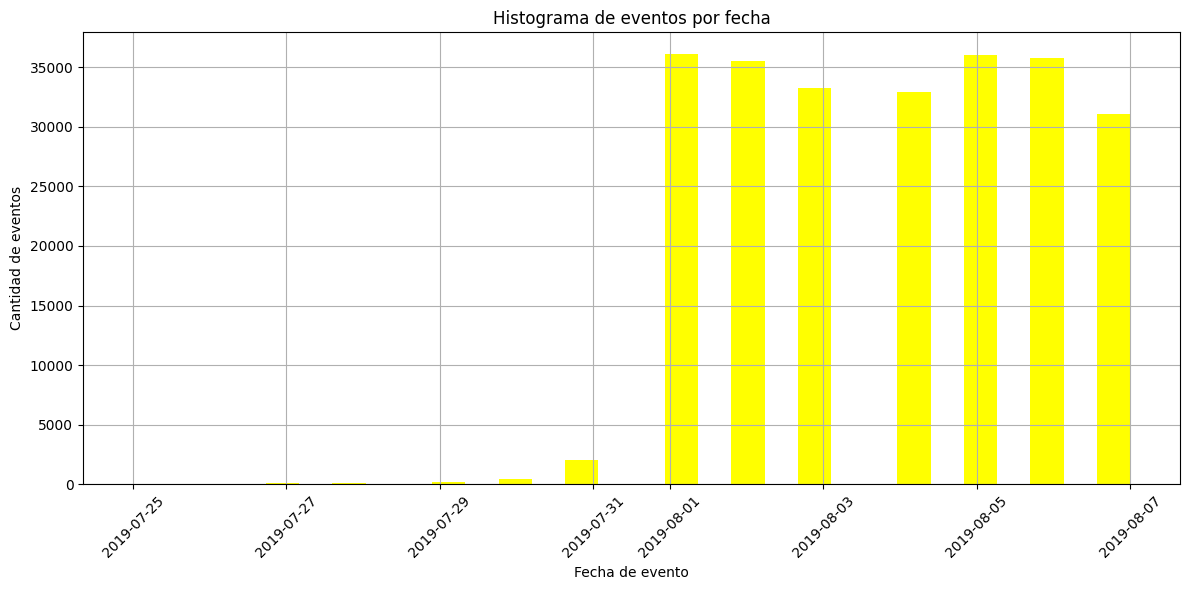

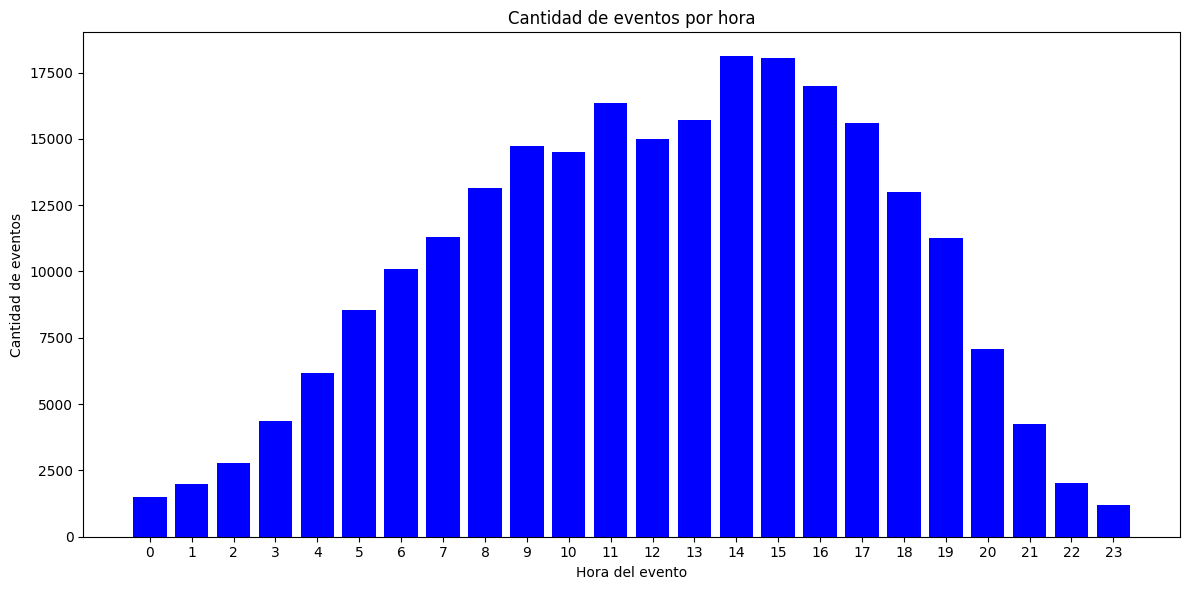

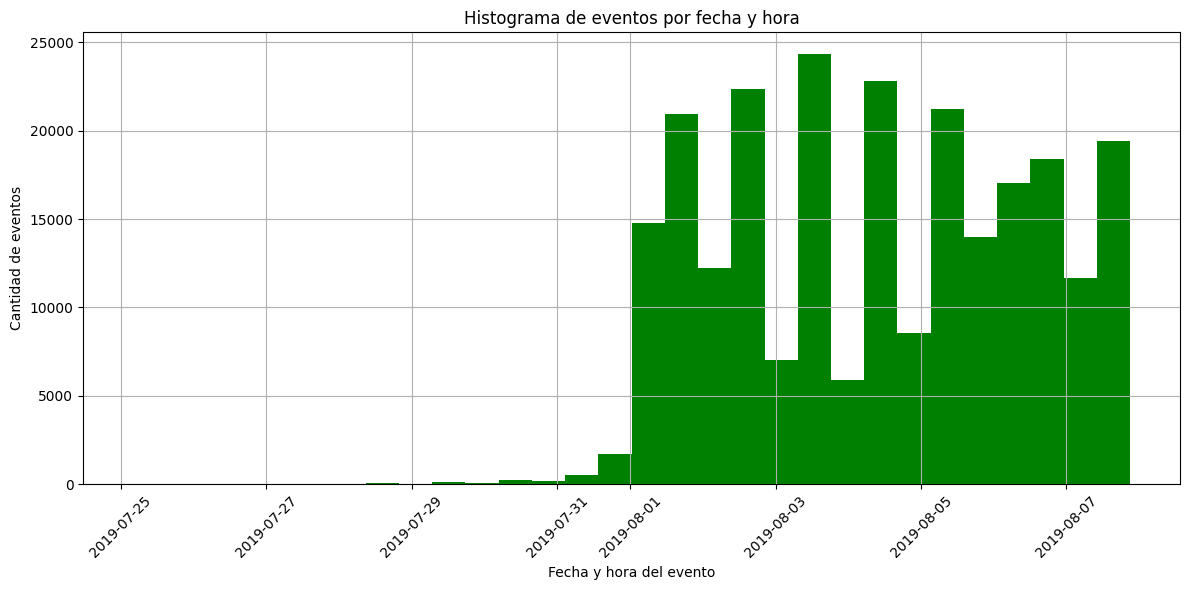

In [10]:
#Encontramos la fecha maxima y mínima de los eventos
min_date = logs['event_date'].min()
max_date = logs['event_date'].max()
print(f'\nFecha mínima de eventos: {min_date}')
print(f'Fecha máxima de eventos: {max_date}')

#Generamos un histograma por fecha de los eventos
logs['event_date'] = pd.to_datetime(logs['event_date'])
plt.figure(figsize=(12, 6))
logs['event_date'].hist(bins=30, color='yellow')
plt.title('Histograma de eventos por fecha')
plt.xlabel('Fecha de evento')
plt.ylabel('Cantidad de eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Agrupamos en un DataFrame los eventos por hora
events_by_hour = logs.groupby(logs['event_timestamp'].dt.hour)['event_name'].count().reset_index()
#Generamos un gráfica de barras por hora de los eventos
plt.figure(figsize=(12, 6))
plt.bar(events_by_hour['event_timestamp'], events_by_hour['event_name'], color='blue')
plt.title('Cantidad de eventos por hora')
plt.xlabel('Hora del evento')
plt.ylabel('Cantidad de eventos')
plt.xticks(events_by_hour['event_timestamp'])
plt.tight_layout()
plt.show()

#Generamos un histograma de eventos por fecha y hora
logs['event_date_time'] = logs['event_timestamp'].dt.floor('h')
plt.figure(figsize=(12, 6))
logs['event_date_time'].hist(bins=30, color='green')
plt.title('Histograma de eventos por fecha y hora')
plt.xlabel('Fecha y hora del evento')
plt.ylabel('Cantidad de eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
#Buscaremos los días y horas que concentran el 95% de los eventos
#Calcularemos el percentil 2.5% y el percentil 97.5% tanto por fecha como por hora
date_q025 = logs['event_date'].quantile(0.025)
date_q975 = logs['event_date'].quantile(0.975)
hour_q025 = logs['event_timestamp'].dt.hour.quantile(0.025)
hour_q975 = logs['event_timestamp'].dt.hour.quantile(0.975)

#Imprimimos la fecha minima y máxima de eventos para encontrar los días que concentran el 95% de los eventos
print(f'\nFecha mínima de eventos (2.5%): {date_q025}')
print(f'Fecha máxima de eventos (97.5%): {date_q975}')

#Igualmente para las horas
print(f'\nHora mínima de eventos (2.5%): {hour_q025}')
print(f'Hora máxima de eventos (97.5%): {hour_q975}')

#Filtramos el DataFrame para quedarnos con los eventos que están dentro del rango del 95%
logs_filtered = logs[(logs['event_date'] >= date_q025) & (logs['event_date'] <= date_q975) &
                     (logs['event_timestamp'].dt.hour >= hour_q025) & (logs['event_timestamp'].dt.hour <= hour_q975)]
#Mostramos la cantidad de eventos filtrados
print(f'\nCantidad de eventos filtrados (95%): {logs_filtered.shape[0]}')


Fecha mínima de eventos (2.5%): 2019-08-01 00:00:00
Fecha máxima de eventos (97.5%): 2019-08-07 00:00:00

Hora mínima de eventos (2.5%): 2.0
Hora máxima de eventos (97.5%): 21.0

Cantidad de eventos filtrados (95%): 234614


    - Como podemos observar en las gráficas nos encontramos ciertos días en los que los usuarios realizarón la mayor cantidad de eventos, siendo estos del 01 al 07 de agosto de 2017. Así como encontramos los horarios con mayores interacciones siendo la ventana de 2 a 21 horas. Ambos rangos corresponden al 95% de la concentración de datos.
    - El DF de LOG será filtrado tomado en cuenta estos rangos para eliminar los datos extremos.

### 3.5 - ¿Perdiste muchos eventos y usuarios al excluir los datos más antiguos?

In [12]:
#Imprimimos los tipos de eventos únicos en el DataFrame filtrado
print('\nTipos de eventos únicos en el DataFrame filtrado:')
print(logs_filtered['event_name'].value_counts())

#Contamos la cantidad de datos por evento de diferencia entre el DataFrame filtrado y el original
print('\nCantidad de eventos entre el DataFrame filtrado y el original:')
print(logs_filtered['event_name'].value_counts() - logs['event_name'].value_counts() )

#Imprimimos la diferencia de dispositivos únicos entre el DataFrame filtrado y el original
print('\nDiferencia de dispositivos únicos entre el DataFrame filtrado y el original: ',
      logs_filtered['device_id_hash'].nunique(), '-', logs['device_id_hash'].nunique(), '=',
      logs_filtered['device_id_hash'].nunique() - logs['device_id_hash'].nunique())


Tipos de eventos únicos en el DataFrame filtrado:
event_name
MainScreenAppear           114122
OffersScreenAppear          45167
CartScreenAppear            41322
PaymentScreenSuccessful     33056
Tutorial                      947
Name: count, dtype: int64

Cantidad de eventos entre el DataFrame filtrado y el original:
event_name
MainScreenAppear          -4979
OffersScreenAppear        -1641
CartScreenAppear          -1346
PaymentScreenSuccessful   -1062
Tutorial                    -71
Name: count, dtype: int64

Diferencia de dispositivos únicos entre el DataFrame filtrado y el original:  7509 - 7551 = -42


### 3.6 - Asegúrate de tener usuarios de los tres grupos experimentales.

In [13]:
#Agrupamos los datos por exp_id y los contamos
exp_counts = logs_filtered.groupby('exp_id')['event_name'].count().reset_index()
#Renombramos la columna 'event_name' a 'event_count'
exp_counts.rename(columns={'event_name': 'event_count'}, inplace=True)
#Mostramos el conteo de eventos por exp_id
print('\nConteo de eventos por exp_id:')
print(exp_counts)


Conteo de eventos por exp_id:
   exp_id  event_count
0     246        77809
1     247        75061
2     248        81744


   - Al filtrar los datos por los rangos obtenemos una disminución en la cantidad de eventos de menos del 4% por cada evento, así como 42 dispositivos únicos menos en comparación al set completo de datos.
   - Tambien nos encontramos con suficientes datos para los grupos de control (246 y 247), así como del grupo de prueba (248) para continuar con los experimentos y las comprobaciones de hipótesis.

## 4 - Estudiar el embudo de eventos

### 4.1 - Observa qué eventos hay en los registros y su frecuencia de suceso. 
Ordénalos por frecuencia.

In [14]:
#Agrupamos el DataFrame filtrado por 'event_name' de forma descendente
event_counts = logs_filtered['event_name'].value_counts()
#Renombramos las columnas del DataFrame
event_counts.columns = ['event_name', 'count']
#Mostramos el conteo de eventos por nombre de evento
print('\nConteo de eventos por nombre de evento:')
print(event_counts)


Conteo de eventos por nombre de evento:
event_name
MainScreenAppear           114122
OffersScreenAppear          45167
CartScreenAppear            41322
PaymentScreenSuccessful     33056
Tutorial                      947
Name: count, dtype: int64


### 4.2 - Encuentra la cantidad de usuarios que realizaron cada una de estas acciones. 
Ordena los eventos por el número de usuarios. Calcula la proporción de usuarios que realizaron la acción al menos una vez.

In [15]:
#Agregamos los datos por 'event_name' y contaremos la cantidad de devices únicos por evento
event_device_counts = logs_filtered.groupby('event_name')['device_id_hash'].nunique().reset_index()
#Renombramos la columna 'device_id_hash' a 'unique_device_count'
event_device_counts.rename(columns={'device_id_hash': 'unique_device_count'}, inplace=True)
#Ordenamos el DataFrame por 'unique_device_count' de forma descendente
event_device_counts.sort_values(by='unique_device_count', ascending=False, inplace=True)
#Mostramos el conteo de dispositivos únicos por nombre de evento
print('\nConteo de dispositivos únicos por nombre de evento:')
print(event_device_counts)


Conteo de dispositivos únicos por nombre de evento:
                event_name  unique_device_count
1         MainScreenAppear                 7392
2       OffersScreenAppear                 4570
0         CartScreenAppear                 3725
3  PaymentScreenSuccessful                 3533
4                 Tutorial                  814


### 4.3 - ¿En qué orden crees que ocurrieron las acciones? ¿Todas son parte de una sola secuencia? 
No es necesario tenerlas en cuenta al calcular el embudo.


    - De forma lógica y como practicamente en todo funnel la mayor cantidad de usuarios se dá en la primera etapa del proceso y conforme van disminuyendo surgen las siguientes etapas.
    - Para este caso los usuarios siguen en el siguiente proceso: abren la pantalla principal -> continuan a la pantalla de ofertas (precios) -> llegan el carrito de compras -> se topan con el formulario de pagos -> comienzan el tutorial.
    - Si comparamos la cantidad de eventos contra los usuarios únicos por etapas notamos ciertas diferencia en el radio de conversion entre cada paso, sin embargo es mucho más importante conocer la cantidad de usuarios que avanzan entre etapas a la cantidad de veces que dicha etapa fue convocada. 
    - Entre cada etapa del proceso va disminuyendo la cantidad de usuarios, si nos enfocamos entre cuales etapas se da la menor disminución es entre el "Carrito de compras" y la "Pantalla de Pagos", sin embargo y como es costumbre en la ultima etapa del proceso el "Tutorial" se da el mayor desplome de usuarios.

### 4.4 - Utiliza el embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente. 
Por ejemplo, para la secuencia de eventos A → B → C, calcula la proporción de usuarios en la etapa B a la cantidad de usuarios en la etapa A y la proporción de usuarios en la etapa C a la cantidad en la etapa B.


Funnel de eventos:
Visitantes en la pantalla principal: 7392
Visitantes en la pantalla de ofertas: 4178
Visitantes en el carrito: 1756
Visitantes en la pantalla de pago: 449
Visitantes en el tutorial: 1

Tasa de conversión por etapa del funnel:
MainScreenAppear: 100.00%
OffersScreenAppear: 56.52%
CartScreenAppear: 42.03%
PaymentScreenSuccessful: 25.57%
Tutorial: 0.22%


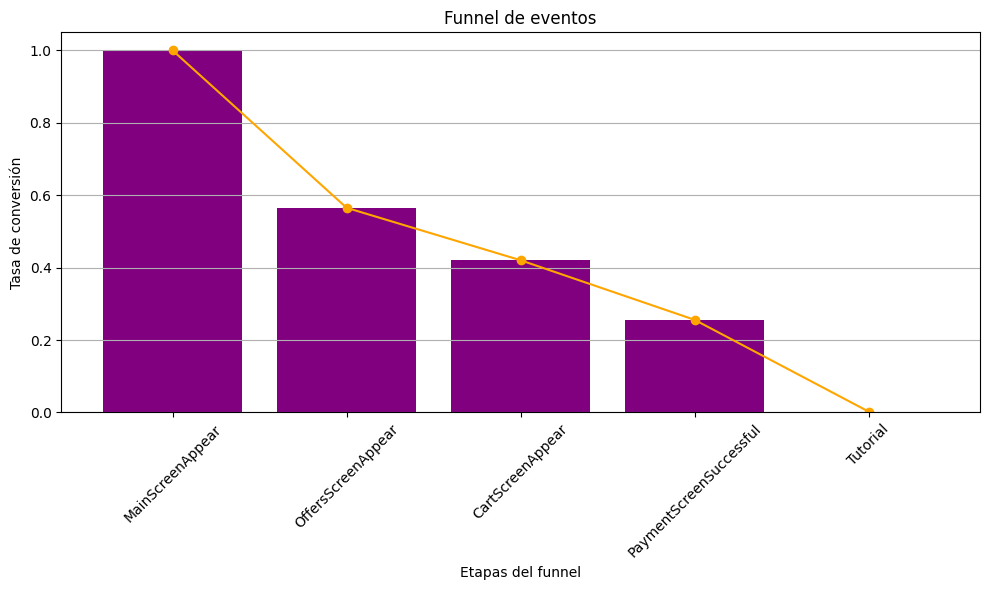

In [16]:
#Generamos una pivot table para contar la cantidad de usuarios únicos por evento
funnel= logs_filtered.pivot_table(index='device_id_hash',
                                  columns='event_name',
                                  values='event_timestamp',
                                  aggfunc='min')

#Renombramos las columnas de la pivot table
funnel.rename(columns={'device_id_hash': 'unique_users'}, inplace=True)

#Ordenamos la pivot table por etapas de eventos de forma ascendente
step_1= ~funnel['MainScreenAppear'].isna()
step_2 = step_1 & (funnel['OffersScreenAppear'] > funnel['MainScreenAppear'])
step_3 = step_2 & (funnel['CartScreenAppear'] > funnel['OffersScreenAppear'])
step_4 = step_3 & (funnel['PaymentScreenSuccessful'] > funnel['CartScreenAppear'])
step_5 = step_4 & (funnel['Tutorial'] > funnel['PaymentScreenSuccessful'])

#Contamos la cantidad de usuarios únicos por etapa del funnel
n_mainscreen = funnel[step_1].shape[0]
n_offerscreen = funnel[step_2].shape[0]
n_cartscreen = funnel[step_3].shape[0]
n_paymentscreen = funnel[step_4].shape[0]
n_tutorial = funnel[step_5].shape[0]

print('\nFunnel de eventos:')
print('Visitantes en la pantalla principal:', n_mainscreen)
print('Visitantes en la pantalla de ofertas:', n_offerscreen)
print('Visitantes en el carrito:', n_cartscreen)
print('Visitantes en la pantalla de pago:', n_paymentscreen)
print('Visitantes en el tutorial:', n_tutorial)

#Calculamos la tasa de conversión por etapa del funnel
conversion_rates = {
    'MainScreenAppear': n_mainscreen / n_mainscreen,
    'OffersScreenAppear': n_offerscreen / n_mainscreen,
    'CartScreenAppear': n_cartscreen / n_offerscreen,
    'PaymentScreenSuccessful': n_paymentscreen / n_cartscreen,
    'Tutorial': n_tutorial / n_paymentscreen
}
#Mostramos la tasa de conversión por etapa del funnel
print('\nTasa de conversión por etapa del funnel:')
for step, rate in conversion_rates.items():
    print(f'{step}: {rate:.2%}')

#Generamos un gráfico de barras con linea de tendencia para visualizar el funnel
plt.figure(figsize=(10, 6))
plt.bar(conversion_rates.keys(), conversion_rates.values(), color='purple')
plt.plot(conversion_rates.keys(), conversion_rates.values(), color='orange', marker='o')
plt.title('Funnel de eventos')
plt.xlabel('Etapas del funnel')
plt.ylabel('Tasa de conversión')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 4.5 - ¿En qué etapa pierdes más usuarios?

    - Al analisar la tasa de conversión de usuarios entre etapas queda más que confirmado que solo el 0.22% de dispositivos únicos la que alcanza la ultima etapa, siendo  esta conversión un porcentaje minusculo.
    - Al observar la gráfica de conversión por etapas del funnel llama la atención que se pierde cerca del 50% de los dispositivos entre la primera y la segunda etapa del proceso.

### 4.6 - ¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?

In [17]:
#Calculamos la tasa de conversión de usuarios que pasaron por todos los eventos del funnel
total_users = funnel.shape[0]
conversion_rate = n_tutorial / total_users
print(f'Porcentaje de usuarios que recorrrieron todo el funnel: {conversion_rate:.3%}')

Porcentaje de usuarios que recorrrieron todo el funnel: 0.013%


    - Al calcular este porcentaje resulta impactante conocer que solo el 0.013% de los usuarios llegan a completar todo el proceso del funnel, esto puede demostrar el bajo desempeño del proceso de ventas y amerita una investigación más extenuante sobre el porque los usuarios están teniendo problemas entre la página de pagos y el tutorial.

## 5 - Estudiar los resultados del experimento

### 5.1 - ¿Cuántos usuarios hay en cada grupo?

In [18]:
#Calculamos la cantidad de usuarios por exp_id 
exp_user_counts = logs_filtered.groupby('exp_id')['device_id_hash'].nunique().reset_index()
#Renombramos la columna 'device_id_hash' a 'unique_user_count'
exp_user_counts.rename(columns={'device_id_hash': 'unique_user_count'}, inplace=True)
#Mostramos la cantidad de usuarios por exp_id
print('\nCantidad de usuarios por exp_id:')
print(exp_user_counts)


Cantidad de usuarios por exp_id:
   exp_id  unique_user_count
0     246               2476
1     247               2505
2     248               2528


### 5.2 - Tenemos dos grupos de control en el test A/A, donde comprobamos nuestros mecanismos y cálculos. 
Observa si hay una diferencia estadísticamente significativa entre las muestras 246 y 247.

In [19]:
#Verificamos si existe diferencia estadística entre los grupos de exp_id 246 y 247
exp_246 = logs_filtered[logs_filtered['exp_id'] == 246]['event_name'].value_counts()
exp_247 = logs_filtered[logs_filtered['exp_id'] == 247]['event_name'].value_counts()
#Realizamos una prueba de hipótesis para comparar las proporciones de eventos entre los dos grupos
#Utilizamos la prueba Mann-Whitney U para comparar las distribuciones de los dos grupos y un alpha de 0.05
stat, p_value = st.mannwhitneyu(exp_246, exp_247, alternative='two-sided')

alpha = 0.0025 #Aplha reajustado conforme al punto 5.5

print(f'\nEstadístico de la prueba: {stat}, p-valor: {p_value}')
if p_value < alpha:
    print('Existe diferencia estadística entre los grupos de exp_id 246 y 247 (rechazamos la hipótesis nula)')
else:
    print('No existe diferencia estadística entre los grupos de exp_id 246 y 247 (no rechazamos la hipótesis nula)')


Estadístico de la prueba: 12.0, p-valor: 1.0
No existe diferencia estadística entre los grupos de exp_id 246 y 247 (no rechazamos la hipótesis nula)


* Las siguientes conclusiones fueron actualizados con el valor ajustado de alpha del punto 5.5
    - Existen sufiecientes usuarios distribuidos entre los 3 grupos para realizar las pruebas. Por lo que lo siguiente a comprobar es que los grupos de control no cucenten con diferencia estadisiticamente significativa entre sí ya que son parte de nuestro primer experimento A/A.
    - Ya que solo queremos conocer si existe una diferencia entre las distribuciones aplicamos el test Mann-Whitney U, después de realizar esta prueba los resultado arrojados indican que NO existe diferencia siginifcativa y que por lo tanto Rechazamos la hipótesis nula.

### 5.3 - Selecciona el evento más popular. 
En cada uno de los grupos de control, encuentra la cantidad de usuarios que realizaron esta acción. Encuentra su proporción. Comprueba si la diferencia entre los grupos es estadísticamente significativa. Repite el procedimiento para todos los demás eventos (ahorrarás tiempo si creas una función especial para esta prueba). ¿Puedes confirmar que los grupos se dividieron correctamente?

In [32]:
#Creamos una función en la que enviamos 1 DF, 2 gruposs de control (exp_id 246 y 247) y una columna (nombre de evento) 
#para comparar si en ese evento de la serie EVENT_NAME tienen diferencias estadísticas con una prueba ztest de proporciones
#contamos la cantidad de usuarios únicos por evento en cada grupo y calculamos la proporciones sobre el total de usuarios únicos en cada grupo.
def compare_event_proportions(df, exp_id_1, exp_id_2, event_name):
    group_1 = df[df['exp_id'] == exp_id_1]['device_id_hash'].nunique()
    group_2 = df[df['exp_id'] == exp_id_2]['device_id_hash'].nunique()
    
    event_count_1 = df[(df['exp_id'] == exp_id_1) & (df['event_name'] == event_name)]['device_id_hash'].nunique()
    event_count_2 = df[(df['exp_id'] == exp_id_2) & (df['event_name'] == event_name)]['device_id_hash'].nunique()
    
    counts = np.array([event_count_1, event_count_2])
    nobs = np.array([group_1, group_2])
    
    stat, p_value = proportions_ztest(counts, nobs)
    
    print(f'\nComparación de proporciones para el evento "{event_name}" entre exp_id {exp_id_1} y {exp_id_2}:')
    print(f'Estadístico de la prueba: {stat}, p-valor: {p_value}')

    #Valor de alpha= 0.0025, reajustado conforme al punto 5.5
    #alpha = 0.05
    if p_value < alpha:
        print('Existe diferencia estadística entre los grupos (Rechazamos la hipótesis nula)')
    else:
        print('No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)')

#Generamos una lista con los nombres de todos los eventos con mayor cantidad de usuarios de manera descendente
top_events = logs_filtered['event_name'].value_counts().index[:10].tolist()

#Iteramos sobre la lista de eventos y comparamos los grupos de control para cada evento
for event in top_events:
    compare_event_proportions(logs_filtered, 246, 247, event)


Comparación de proporciones para el evento "MainScreenAppear" entre exp_id 246 y 247:
Estadístico de la prueba: 0.42509283931145286, p-valor: 0.6707689977271798
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Comparación de proporciones para el evento "OffersScreenAppear" entre exp_id 246 y 247:
Estadístico de la prueba: 1.0388291766586786, p-valor: 0.2988841893592147
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Comparación de proporciones para el evento "CartScreenAppear" entre exp_id 246 y 247:
Estadístico de la prueba: 1.2341406833857451, p-valor: 0.21715048594561825
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Comparación de proporciones para el evento "PaymentScreenSuccessful" entre exp_id 246 y 247:
Estadístico de la prueba: 1.5812497476262208, p-valor: 0.11382094472896491
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Compara

    - Como se quiere conocer la diferencia estadistica de la ocurrencia de cada evento utilizamos proportions Z-test para comprobar las hipótesis.
    - Al comparar evento por evento de ambos grupos de control (246 y 247) encontramos que no existe diferencia significativa entre ellos por lo que esto hace a ambos grupos ideales para nuestra prueba A/A, las pruebas se realizaron tanto con el valor de alpha elegido de forma inical a=0.05 así como el ajustado de 0.0025.
    - Notamos que para el evento Tutorial el valor P es particularmente alto lo que da a entender una muy alta similitud entre grupos.

### 5.4 - Haz lo mismo para el grupo con fuentes alteradas. 
Compara los resultados con los de cada uno de los grupos de control para cada evento de forma aislada. Compara los resultados con los resultados combinados de los grupos de control. ¿Qué conclusiones puedes sacar del experimento?

In [36]:
#Utilizamos la función nuevamente para comparar todos los eventos ahora entre el grupo de control 246 y el grupo de prueba 248
for event in top_events:
    compare_event_proportions(logs_filtered, 246, 248, event)


Comparación de proporciones para el evento "MainScreenAppear" entre exp_id 246 y 248:
Estadístico de la prueba: 1.1544442731054962, p-valor: 0.24831807297481734
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Comparación de proporciones para el evento "OffersScreenAppear" entre exp_id 246 y 248:
Estadístico de la prueba: 1.1527217676743255, p-valor: 0.24902460388459413
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Comparación de proporciones para el evento "CartScreenAppear" entre exp_id 246 y 248:
Estadístico de la prueba: 1.8060623612038966, p-valor: 0.07090859921099225
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Comparación de proporciones para el evento "PaymentScreenSuccessful" entre exp_id 246 y 248:
Estadístico de la prueba: 1.3218315051537575, p-valor: 0.18622426479589782
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Compar

    - Ahora comparamos el grupo de control 246 y el grupo de prueba 248, identificamos que en todos los eventos los grupos no muestran diferencias significativas estadisticas y confirmamos que los usuarios en ambos casos muestran un comportamiento similar.
    - El valor P más cercano a alpha se da en el evento CartScreenAppear, sin embargo sigue estando muy por encima en especial del alpha corregido.

In [34]:
#Ahora comparamos el grupos de control 247 y el grupo de prueba 248
for event in top_events:
    compare_event_proportions(logs_filtered, 247, 248, event)


Comparación de proporciones para el evento "MainScreenAppear" entre exp_id 247 y 248:
Estadístico de la prueba: 0.7327916027954305, p-valor: 0.4636855436608668
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Comparación de proporciones para el evento "OffersScreenAppear" entre exp_id 247 y 248:
Estadístico de la prueba: 0.11190234531400246, p-valor: 0.9109008369939195
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Comparación de proporciones para el evento "CartScreenAppear" entre exp_id 247 y 248:
Estadístico de la prueba: 0.5709183009403157, p-valor: 0.5680550248064093
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Comparación de proporciones para el evento "PaymentScreenSuccessful" entre exp_id 247 y 248:
Estadístico de la prueba: -0.2638358001422301, p-valor: 0.791906447133365
No existe diferencia estadística entre los grupos (NO rechazamos la hipótesis nula)

Comparaci

    - En esta segunda comparación de un grupo de control (247) contra el de prueba (248) continua esta alta simulitud estadistica entre los grupos en todos los eventos incluso más que con el grupo de control (246).

In [23]:
#Combinamos los grupos de control 246 y 247 solo en sus usuarios únicos
combined_control = logs_filtered[logs_filtered['exp_id'].isin([246, 247])]
logs_combined = logs_filtered.copy()

#Asignamos un nuevo exp_id para el grupo combinado, será el 999 para diferenciarlos
logs_combined.loc[logs_combined['exp_id'].isin([246, 247]), 'exp_id'] = 999

#Ahora comparamos el grupo combinado de control con el grupo de prueba 248
for event in top_events:
    compare_event_proportions(logs_combined, 999, 248, event)


Comparación de proporciones para el evento "MainScreenAppear" entre exp_id 999 y 248:
Estadístico de la prueba: 1.106245423582183, p-valor: 0.2686203070080926
No existe diferencia estadística entre los grupos (no rechazamos la hipótesis nula)

Comparación de proporciones para el evento "OffersScreenAppear" entre exp_id 999 y 248:
Estadístico de la prueba: 0.7279204944043511, p-valor: 0.4666622567873764
No existe diferencia estadística entre los grupos (no rechazamos la hipótesis nula)

Comparación de proporciones para el evento "CartScreenAppear" entre exp_id 999 y 248:
Estadístico de la prueba: 1.3709010134321373, p-valor: 0.1704058153981024
No existe diferencia estadística entre los grupos (no rechazamos la hipótesis nula)

Comparación de proporciones para el evento "PaymentScreenSuccessful" entre exp_id 999 y 248:
Estadístico de la prueba: 0.6081002179059654, p-valor: 0.5431210077280861
No existe diferencia estadística entre los grupos (no rechazamos la hipótesis nula)

Comparación

    - Creamos un nuevo grupo de control (999) al unificar los grupos 246 y 247 para compararlos nuevamente contra el grupo de prueba (248) para saber si de esta forma se muestra una diferencia entre los grupos, sin embargo la tendencia continúa y la similitud estadistica tan marcada sigue surgiendo.

### 5.5 - ¿Qué nivel de significancia has establecido para probar las hipótesis estadísticas mencionadas anteriormente? 
Calcula cuántas pruebas de hipótesis estadísticas has realizado. Con un nivel de significancia estadística de 0.1, uno de cada 10 resultados podría ser falso. ¿Cuál debería ser el nivel de significancia? Si deseas cambiarlo, vuelve a ejecutar los pasos anteriores y comprueba tus conclusiones.

In [35]:
#Se cuenta con 5 eventos y se realizaron 4 pruebas de hipótesis
n_events= len(logs_filtered['event_name'].unique())
n_tests = 4
#Calculamos el total de pruebas de hipótesis realizadas
total_tests = n_events * n_tests
print(f'\nTotal de pruebas de hipótesis realizadas: {total_tests}')

#Asignamos un nivel de significancia de 0.05, fue utilizado en las pruebas anteriores antes de la corrección de Bonferroni
alpha_ant = 0.05

#Calculamos los falsos positivos esperados
expected_false_positives = total_tests * alpha
print(f'Falsos positivos esperados por cada 10 tests al nivel de significancia {alpha_ant}: {expected_false_positives}')

#Calculamos el nivel de significancia corregido por el número de pruebas realizadas
#Utilizamos la corrección de Bonferroni para ajustar el nivel de significancia
corrected_alpha = alpha_ant / total_tests
print(f'Nivel de significancia corregido por Bonferroni: {corrected_alpha}')


Total de pruebas de hipótesis realizadas: 20
Falsos positivos esperados por cada 10 tests al nivel de significancia 0.05: 0.05
Nivel de significancia corregido por Bonferroni: 0.0025


    - Anteriormente se estableción un aplha= 0.05 de forma conservadora, sin embargo por la cantidad de experimentos encontramos que de los 20 totales al menos 1 podría dar un falso positivo por lo que reajustamos el valor conforme a la corrección de Bonferronu obteniendo un valor de P=0.0025.
    - Este nuevo valor solo reduce la posibilidad de un falso positivo sin embargo ninguno de los resulatados de los experimentos anterior se encuentra siquiera cercano a este valor o al anterior.

## Conclusiones

Durante el periodo del 1 al 7 de agosto de 2019, se registraron 234,614 eventos realizados por 7,551 dispositivos únicos, con un promedio de 32 eventos por dispositivo. Se evaluaron cinco tipos de eventos clave: MainScreenAppear, OffersScreenAppear, CartScreenAppear, PaymentScreenSuccessful y Tutorial. El experimento comparó el comportamiento de los usuarios entre tres grupos (246, 247 y 248), además de una versión combinada (grupo 999), con el objetivo de detectar diferencias significativas en la interacción del usuario con la app.

Se realizaron pruebas z para comparar proporciones entre los grupos, tanto con un α = 0.05 como con una corrección estricta de α = 0.0025. En todos los casos, no se encontraron diferencias estadísticamente significativas en ninguno de los eventos analizados. Incluso al combinar los grupos 247 y 248 en un grupo mayor (999), los resultados siguieron mostrando comportamientos estadísticamente indistinguibles entre los usuarios. Esto indica que los cambios aplicados en el grupo experimental 248 no generaron un impacto medible en los eventos clave.

A nivel de funnel, se observa que el 100% de los usuarios llegaron a la pantalla principal, pero solo 56.5% accedieron a la pantalla de ofertas, 42% al carrito, y solo 25.6% llegaron a la pantalla de pago. El evento Tutorial tuvo una participación casi nula (0.22%). Este embudo revela puntos de fuga importantes en la conversión, especialmente entre el carrito y el pago. Sin embargo, estos patrones de comportamiento se mantuvieron constantes entre todos los grupos. En resumen, ni el volumen ni el tipo de evento ni el grupo experimental alteraron el flujo de navegación de los usuarios, lo que sugiere que el diseño actual del experimento no logró activar cambios significativos en la experiencia del usuario.